<span style='font-size:24px; display:block;'>
Download data from database (influxdb)
</span>

<span style='font-size:40px; display:block;'>    
<b>Download data for specific variables</b></br>    
</span>

---
**Author**: Lukas Hörtnagl  
**Last update**: 19 Mar 2025

# Imports

In [1]:
import numpy as np
import warnings
from datetime import datetime
import dbc_influxdb as dbc
warnings.simplefilter("ignore")

# Connect to database

In [2]:
# Folder with database configurations
DIRCONF = r'C:\Users\holukas\Sync\luhk_work\20 - CODING\22 - POET\configs'
# DIRCONF = r'L:\Sync\luhk_work\20 - CODING\22 - POET\configs'  
# Instantiate class
dbc = dbc.dbcInflux(dirconf=DIRCONF)

Reading configuration files was successful.
Connection to database works.


# General settings

In [3]:
# Settings
SITE = 'ch-dav'  # Site name
BUCKET = f'{SITE}_processed'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)

# SW_OUT

## Download from old meteoscreening `_mst`

In [4]:
MEASUREMENTS = ['SW']  # Measurement name
FIELDS = ['SW_OUT_T1_35_1', 'SW_OUT_T1_35_2']  # Variable name; InfluxDB stores variable names as '_field'
DATA_VERSION = ['meteoscreening_mst']
START = '1997-01-01 00:00:01'  # Download data starting with this date
STOP = '2022-01-01 00:00:01'  # Download data before this date (the stop date itself is not included)
sw_out, data_detailed, assigned_measurements = \
    dbc.download(bucket=BUCKET, measurements=MEASUREMENTS, fields=FIELDS, start=START, stop=STOP, 
                 timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS, data_version=DATA_VERSION)


DOWNLOADING
    from bucket ch-dav_processed
    variables ['SW_OUT_T1_35_1', 'SW_OUT_T1_35_2']
    from measurements ['SW']
    from data version ['meteoscreening_mst']
    between 1997-01-01 00:00:01 and 2022-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-dav_processed") |> range(start: 1997-01-01T00:00:01+01:00, stop: 2022-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "SW_OUT_T1_35_1" or r["_field"] == "SW_OUT_T1_35_2") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-dav_processed") |> range(start: 1997-01-01T00:00:01+01:00, stop: 2022-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "SW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "SW_OUT_T1_35_1" or r["_field"] == "SW_OUT_T1_35_2") |> piv

## Plot downloaded data

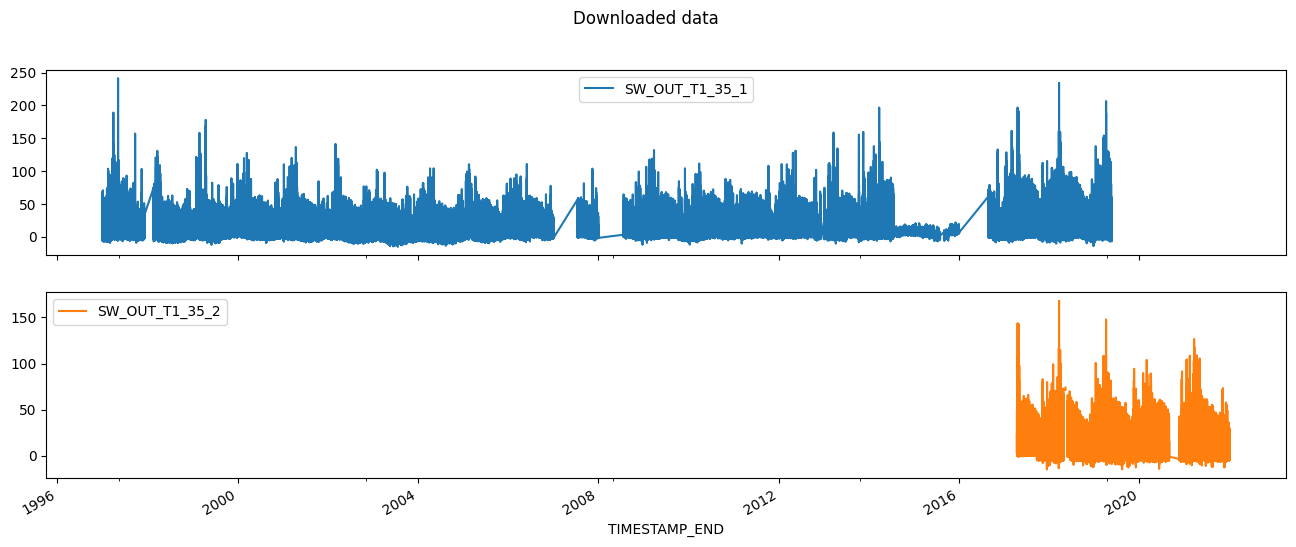

In [5]:
sw_out.plot(x_compat=True, figsize=(16, 6), title="Downloaded data", subplots=True);

## Merge

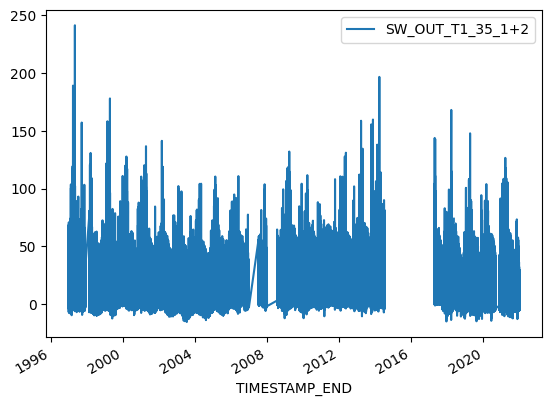

In [6]:
sw_out.loc[sw_out.index >= '2014-07-17', 'SW_OUT_T1_35_1'] = sw_out.loc[sw_out.index >= '2014-07-17', 'SW_OUT_T1_35_2']
sw_out = sw_out['SW_OUT_T1_35_1'].copy()
sw_out.name = 'SW_OUT_T1_35_1+2'
sw_out.plot(x_compat=True, legend=True);

# LW_OUT 

## Download from old meteoscreening `_mst`

In [7]:
MEASUREMENTS = ['LW']  # Measurement name
FIELDS = ['LW_OUT_T1_35_1', 'LW_OUT_T1_35_2']  # Variable name; InfluxDB stores variable names as '_field'
DATA_VERSION = ['meteoscreening_mst']
START = '2006-01-01 00:00:01'  # Download data starting with this date
STOP = '2022-01-01 00:00:01'  # Download data before this date (the stop date itself is not included)
lw_out, data_detailed, assigned_measurements = \
    dbc.download(bucket=BUCKET, measurements=MEASUREMENTS, fields=FIELDS, start=START, stop=STOP, 
                 timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS, data_version=DATA_VERSION)


DOWNLOADING
    from bucket ch-dav_processed
    variables ['LW_OUT_T1_35_1', 'LW_OUT_T1_35_2']
    from measurements ['LW']
    from data version ['meteoscreening_mst']
    between 2006-01-01 00:00:01 and 2022-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-dav_processed") |> range(start: 2006-01-01T00:00:01+01:00, stop: 2022-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "LW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "LW_OUT_T1_35_1" or r["_field"] == "LW_OUT_T1_35_2") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-dav_processed") |> range(start: 2006-01-01T00:00:01+01:00, stop: 2022-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "LW") |> filter(fn: (r) => r["data_version"] == "meteoscreening_mst") |> filter(fn: (r) => r["_field"] == "LW_OUT_T1_35_1" or r["_field"] == "LW_OUT_T1_35_2") |> piv

## Plot downloaded data

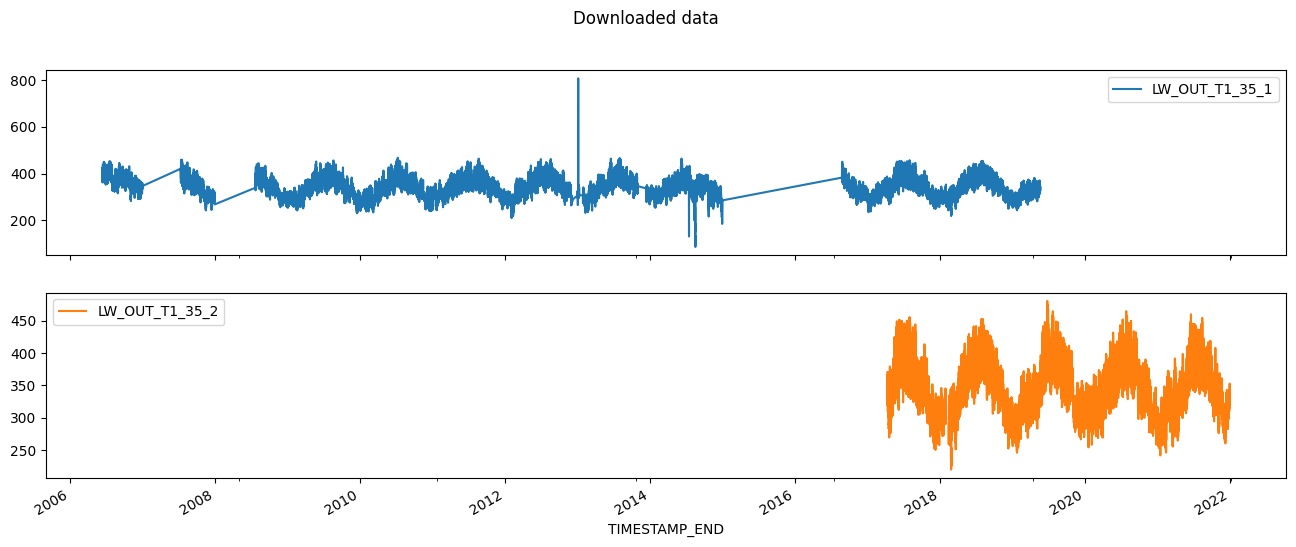

In [8]:
lw_out.plot(x_compat=True, figsize=(16, 6), title="Downloaded data", subplots=True);

## Merge

In [9]:
lw_out.loc[lw_out.index >= '2018-01-01', 'LW_OUT_T1_35_1'] = lw_out.loc[lw_out.index >= '2018-01-01', 'LW_OUT_T1_35_2']
lw_out = lw_out['LW_OUT_T1_35_1'].copy()
lw_out.name = 'LW_OUT_T1_35_1+2'

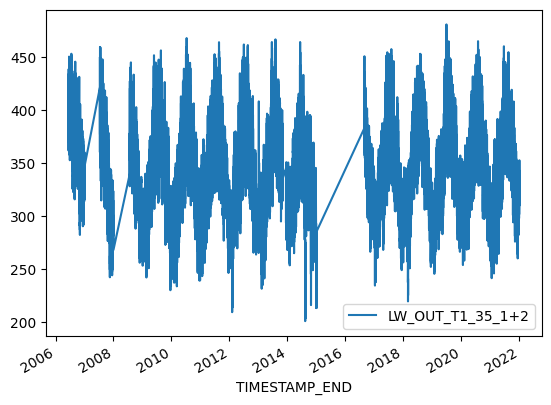

In [10]:
lw_out[lw_out > 500] = np.nan
lw_out[lw_out < 200] = np.nan
lw_out.plot(x_compat=True, legend=True);

# NETRAD

## Download from old meteoscreening `_mst`

In [21]:
MEASUREMENTS = ['NETRAD']  # Measurement name
FIELDS = ['NETRAD_NABEL_T1_35_1']  # Variable name; InfluxDB stores variable names as '_field'
DATA_VERSION = ['meteoscreening_diive']
START = '1997-01-01 00:00:01'  # Download data starting with this date
STOP = '2019-01-01 00:00:01'  # Download data before this date (the stop date itself is not included)
netrad, data_detailed, assigned_measurements = \
    dbc.download(bucket=BUCKET, measurements=MEASUREMENTS, fields=FIELDS, start=START, stop=STOP, 
                 timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS, data_version=DATA_VERSION)


DOWNLOADING
    from bucket ch-dav_processed
    variables ['NETRAD_NABEL_T1_35_1']
    from measurements ['NETRAD']
    from data version ['meteoscreening_diive']
    between 1997-01-01 00:00:01 and 2019-01-01 00:00:01
    with timezone offset to UTC of 1
Using querystring:
from(bucket: "ch-dav_processed") |> range(start: 1997-01-01T00:00:01+01:00, stop: 2019-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "NETRAD") |> filter(fn: (r) => r["data_version"] == "meteoscreening_diive") |> filter(fn: (r) => r["_field"] == "NETRAD_NABEL_T1_35_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
Used querystring: from(bucket: "ch-dav_processed") |> range(start: 1997-01-01T00:00:01+01:00, stop: 2019-01-01T00:00:01+01:00) |> filter(fn: (r) => r["_measurement"] == "NETRAD") |> filter(fn: (r) => r["data_version"] == "meteoscreening_diive") |> filter(fn: (r) => r["_field"] == "NETRAD_NABEL_T1_35_1") |> pivot(rowKey:["_time"], columnKey: ["_field"], valueCol

## Plot downloaded data

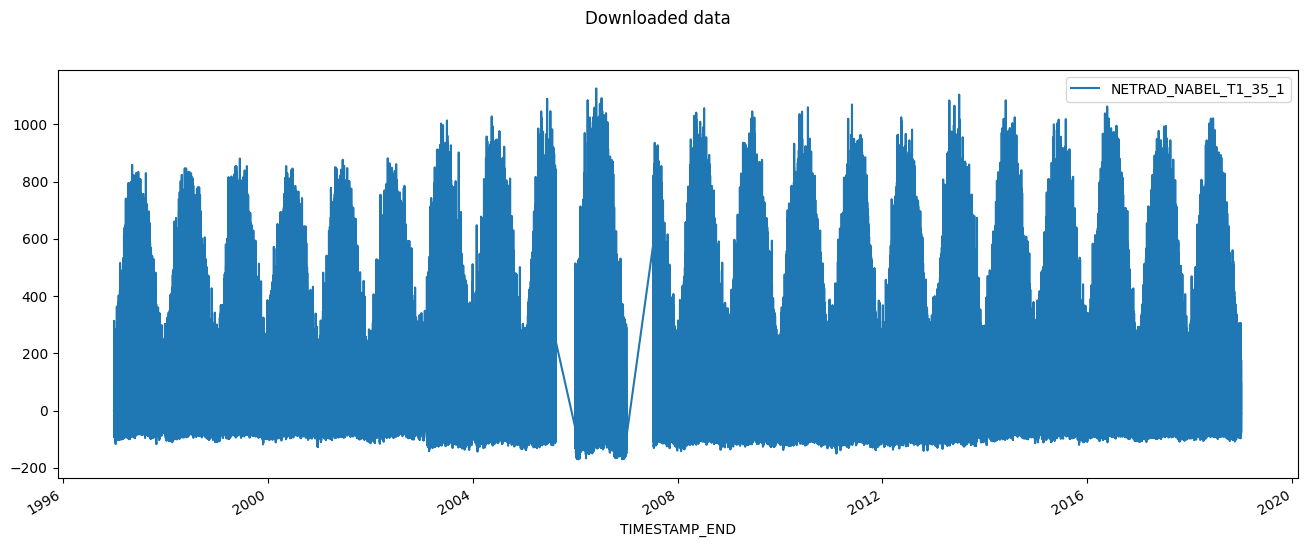

In [22]:
netrad.plot(x_compat=True, figsize=(16, 6), title="Downloaded data", subplots=True);

# Merge dataset

In [23]:
import pandas as pd
merged = pd.concat([sw_out, lw_out, netrad], axis=1)
merged

,SW_OUT_T1_35_1+2,LW_OUT_T1_35_1+2,NETRAD_NABEL_T1_35_1
TIMESTAMP_END,,,
1997-01-01 00:30:00,1.247333,NaN,-0.98
1997-01-01 01:00:00,1.269667,NaN,-1.97
1997-01-01 01:30:00,0.690667,NaN,-0.76
1997-01-01 02:00:00,0.261667,NaN,-0.81
1997-01-01 02:30:00,-0.162000,NaN,-0.36
...,...,...,...
2021-12-31 22:00:00,-2.379841,326.689481,NaN
2021-12-31 22:30:00,-3.172248,325.279502,NaN
2021-12-31 23:00:00,-2.738848,325.669117,NaN


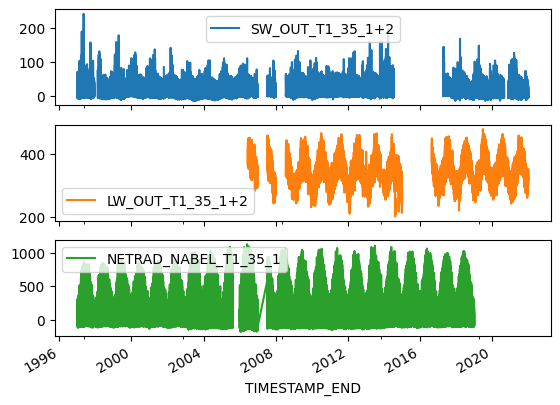

In [26]:
merged.plot(x_compat=True, subplots=True);

# Save to file

In [24]:
merged.to_csv(r"LW_OUT_SW_OUT_NETRAD.csv")

# End of notebook.
Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [25]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-09-11 23:27:49
